![image.png](https://i.imgur.com/a3uAqnb.png)

# Training a Sparse Autoencoder and Steering GPT-2

- **Dataset**: [OpenWebText tokenised for GPT-2](https://huggingface.co/datasets/apollo-research/Skylion007-openwebtext-tokenizer-gpt2) from Hugging Face, streamed, for training, and [NeelNanda/pile-10k](https://huggingface.co/datasets/NeelNanda/pile-10k) (10,000 documents of the Pile) for evaluation
- **Task**: learn a sparse dictionary of the residual-stream activations of one layer, read its features, and use them to steer generation
- **Model**: GPT-2 small (124M, frozen) through SAELens, with a sparse autoencoder of 12,288 latents (about 19M parameters) trained from scratch on the residual stream entering block 7, then compared with the pretrained `gpt2-small-res-jb` SAE
- **Runtime**: Colab A100 GPU, about 20 minutes of compute of which 10 to 15 minutes are training.

In this lab, we will:

- stream a pretokenised corpus and build a held-out token set for evaluation
- configure and run SAELens's training runner on GPT-2 small's residual stream, recording the loss and sparsity as it trains
- evaluate our own SAE with L0, variance explained, loss recovered and dead latents, and compare it with a published SAE of the same layer
- read features from their top-activating tokens and steer generation by clamping one of them
- build a mean-difference steering vector for a known concept and compare it with the learned features

## What is a sparse autoencoder?

A language model stores more features than it has dimensions by packing them as directions that interfere, so one residual-stream dimension means nothing on its own. A sparse autoencoder (SAE) learns a wider basis in which each activation vector $x \in \mathbb{R}^{d}$ is a sum of a few interpretable directions:

$$z = \mathrm{ReLU}(W_{\text{enc}}\, x + b_{\text{enc}}), \qquad \hat{x} = W_{\text{dec}}\, z + b_{\text{dec}}, \qquad \mathcal{L} = \lVert x - \hat{x} \rVert_2^2 + \lambda \lVert z \rVert_1$$

Where:
- $z \in \mathbb{R}^{F}$ are the latent (feature) activations, with $F \gg d$ (here $F = 16d$)
- $W_{\text{enc}} \in \mathbb{R}^{F \times d}$ and $W_{\text{dec}} \in \mathbb{R}^{d \times F}$ are the encoder and decoder, and the columns of $W_{\text{dec}}$ are the feature directions
- $\lambda$ is the sparsity coefficient. The $L_1$ penalty drives most latents to exactly zero, and SAELens weights $|z_i|$ by $\lVert W_{\text{dec}, i} \rVert_2$ so the penalty cannot be dodged by shrinking latents and growing the decoder (Templeton et al., 2024)

An SAE is judged on two things at once: how sparse its code is (L0, the mean number of active latents per token) and how faithful it is (the variance it explains and, more importantly, how much the language-modelling loss rises when the layer's activation is replaced by $\hat{x}$). A trained feature direction can also be written back into the model: clamping one latent and moving $x$ along its decoder column steers what the model says.

Papers: [Bricken et al., 2023. Towards Monosemanticity](https://transformer-circuits.pub/2023/monosemantic-features/index.html), [Templeton et al., 2024. Scaling Monosemanticity](https://transformer-circuits.pub/2024/scaling-monosemanticity/index.html), [Lieberum et al., 2024. Gemma Scope](https://arxiv.org/abs/2408.05147)

## Setup

In Google Colab, select **Runtime > Change runtime type > A100 GPU**, then run the cells from top to bottom. A T4 also works if `TRAINING_TOKENS` is lowered to about 5 million in the config cell. `sae-lens` is not preinstalled on Colab, so the first cell installs it.

In [1]:
%pip install -q sae-lens

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.4/150.4 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.9/320.9 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.9/342.9 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.3/256.3 kB 26.1 MB/s eta 0:00:00


In [2]:
import time
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer

import torch
import torch.nn.functional as F
from sae_lens import (SAE, HookedSAETransformer, LanguageModelSAERunnerConfig, LanguageModelSAETrainingRunner,
                      LoggingConfig, StandardTrainingSAEConfig)

In [3]:
SEED = 42
MODEL_NAME = "gpt2-small"
LAYER = 7
HOOK = f"blocks.{LAYER}.hook_resid_pre"     # the residual stream entering block 7, where the pretrained SAE we compare with lives
D_IN = 768                                  # GPT-2 small residual width
EXPANSION = 16                              # d_sae = EXPANSION * D_IN latents (the pretrained SAE uses 32)
TRAIN_DATASET = "apollo-research/Skylion007-openwebtext-tokenizer-gpt2"   # OpenWebText already tokenised for GPT-2
CONTEXT_SIZE = 256                          # tokens per sequence fed to GPT-2 (each stored row has 1,024, we use its first 256)
TRAINING_TOKENS = 20_000_000                # about 5_000_000 on a T4
BATCH_TOKENS = 4_096                        # SAE batch size, in tokens
LR = 5e-5
L1_COEFFICIENT = 5.0                        # lambda: larger gives a sparser code and a worse reconstruction
L1_WARMUP_FRACTION = 0.05                   # lambda ramps up over the first 5% of steps
LOG_EVERY = 50                              # steps between points on the training curves
EVAL_DATASET = "NeelNanda/pile-10k"
N_EVAL_DOCS = 400                           # documents read from the evaluation set
N_EVAL_SEQS = 128                           # evaluation sequences of CONTEXT_SIZE tokens
EVAL_BATCH = 32
PRETRAINED_RELEASE = "gpt2-small-res-jb"    # Bloom, 2024: one SAE per residual-stream layer of GPT-2 small
NEURONPEDIA = f"gpt2-small/{LAYER}-res-jb"  # dashboards for the pretrained SAE's features
N_INSPECT = 4                               # features whose top tokens we print
TOP_TOKENS = 8
WINDOW = 10                                 # tokens of context shown on each side
STEER_FEATURE = None                        # None steers with the first inspected feature, or set an index
CLAMP_MULTIPLES = [0.0, 5.0, 10.0]          # clamp values as multiples of the feature's maximum activation
GEN_PROMPT = "Tell me a short story about a day at the beach."
MAX_NEW_TOKENS = 50
N_PER_CLASS = 100                           # SST-2 sentences per class for the mean-difference vector
N_VAL_SENTENCES = 200
STEER_COEFFS = [-8.0, 8.0]

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
    if torch.cuda.get_device_capability(0)[0] >= 8:
        torch.set_float32_matmul_precision("high")    # TF32 matmuls on an A100: the SAE trains in float32
else:
    print("No GPU found, so training will be very slow. In Colab: Runtime > Change runtime type > A100 GPU.")

PyTorch 2.11.0+cu130 | device: cuda
GPU: NVIDIA A100-SXM4-40GB (42.4 GB)


## 1. Dataset

- **Source**: [apollo-research/Skylion007-openwebtext-tokenizer-gpt2](https://huggingface.co/datasets/apollo-research/Skylion007-openwebtext-tokenizer-gpt2) on Hugging Face: OpenWebText (Gokaslan and Cohen, 2019) tokenised with the GPT-2 tokeniser by Apollo Research, 8.8 million rows of 1,024 tokens (`input_ids`), parquet
- **What we use**: the stream is read in order until `TRAINING_TOKENS` tokens have been consumed (about 80,000 rows), so the 17 GB dataset is never downloaded in full. The pretrained SAE we compare with was trained on the same corpus
- **Evaluation**: [NeelNanda/pile-10k](https://huggingface.co/datasets/NeelNanda/pile-10k), the first 10,000 documents of the Pile (`text`), 33 MB, BigScience RAIL licence. A different corpus from the training one, so the metrics are mildly out of distribution, as in real use

We first peek at one streamed row to confirm the layout SAELens will read.

In [4]:
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")

stream = load_dataset(TRAIN_DATASET, split="train", streaming=True)
row = next(iter(stream))
print(f"columns: {list(row.keys())}, tokens per row: {len(row['input_ids'])}")
print(repr(tokenizer.decode(row["input_ids"][:40])))
print(f"rows needed for {TRAINING_TOKENS:,} training tokens at {CONTEXT_SIZE} tokens each: {TRAINING_TOKENS // CONTEXT_SIZE:,}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/300 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/73 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/73 [00:00<?, ?it/s]

columns: ['input_ids'], tokens per row: 1024
' up regulated (Clstn3, Cntnap1, and Pclo). The tyrosine kinase receptor, Ntrk2, which has a role in suppressing appetite,'
rows needed for 20,000,000 training tokens at 256 tokens each: 78,125


For evaluation we tokenise Pile documents ourselves, join them with the end-of-text token and cut fixed-length sequences that start with a beginning-of-sequence token, the layout GPT-2 is used to. GPT-2 uses the same id for both tokens.

In [5]:
def tokenize_and_chunk(texts, tokenizer, context_size, n_seqs):
    """Join documents with <|endoftext|> and cut (n_seqs, context_size) sequences, each starting with BOS."""
    ids = []
    for text in texts:
        ids.extend(tokenizer(text)["input_ids"] + [tokenizer.eos_token_id])
        if len(ids) >= n_seqs * (context_size - 1):
            break
    assert len(ids) >= n_seqs * (context_size - 1), "raise N_EVAL_DOCS: the documents hold too few tokens"
    body = torch.tensor(ids[: n_seqs * (context_size - 1)]).view(n_seqs, context_size - 1)
    bos = torch.full((n_seqs, 1), tokenizer.bos_token_id)
    return torch.cat([bos, body], dim=1)                     # (n_seqs, context_size)


pile = load_dataset(EVAL_DATASET, split="train").select(range(N_EVAL_DOCS))
eval_tokens = tokenize_and_chunk(pile["text"], tokenizer, CONTEXT_SIZE, N_EVAL_SEQS).to(DEVICE)
print(eval_tokens.shape, f"| {eval_tokens.numel():,} evaluation tokens")
print(repr(tokenizer.decode(eval_tokens[0, :30])))

README.md:   0%|          | 0.00/373 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/921 [00:00<?, ?B/s]

data/train-00000-of-00001-4746b8785c874c(…): reconstructing file:   0%|          |  0.00B / 33.3MB            

data/train-00000-of-00001-4746b8785c874c(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

torch.Size([128, 256]) | 32,768 evaluation tokens
'<|endoftext|>It is done, and submitted. You can play “Survival of the Tastiest” on Android, and on the web.'


## 2. Model

GPT-2 small is loaded through `HookedSAETransformer`, a TransformerLens `HookedTransformer` that exposes every intermediate activation under a name such as `blocks.7.hook_resid_pre`. The same object produces the activations the SAE trains on, evaluates the SAE by splicing reconstructions into the forward pass, and generates text under steering hooks.

In [6]:
model = HookedSAETransformer.from_pretrained(MODEL_NAME, device=DEVICE)
print(f"{MODEL_NAME}: {model.cfg.n_layers} layers, d_model {model.cfg.d_model}, hook {HOOK}")


@torch.no_grad()
def collect_acts(tokens):
    """Residual-stream activations at HOOK for (B, T) tokens: (B, T, D_IN). The forward stops after that layer."""
    _, cache = model.run_with_cache(tokens, names_filter=[HOOK], stop_at_layer=LAYER + 1)
    return cache[HOOK]


acts = collect_acts(eval_tokens[:EVAL_BATCH])
print(f"activation norm at position 0 (BOS): {acts[:, 0].norm(dim=-1).mean():.0f}, "
      f"at later positions: {acts[:, 1:].norm(dim=-1).mean():.1f}")

/tmp/ipykernel_699/12457934.py:1: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedSAETransformer.from_pretrained(MODEL_NAME, device=DEVICE)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer
gpt2-small: 12 layers, d_model 768, hook blocks.7.hook_resid_pre
activation norm at position 0 (BOS): 3084, at later positions: 89.3


The SAE is described by two SAELens configs. `StandardTrainingSAEConfig` is the ReLU and $L_1$ architecture of the primer. `LanguageModelSAERunnerConfig` says where activations come from (model, hook, dataset, context), how they are buffered and shuffled before the SAE sees them, and how the optimiser runs.

In [7]:
total_steps = TRAINING_TOKENS // BATCH_TOKENS

cfg = LanguageModelSAERunnerConfig(
    # where the activations come from
    model_name=MODEL_NAME,
    hook_name=HOOK,
    dataset_path=TRAIN_DATASET,
    is_dataset_tokenized=True,                 # rows already hold GPT-2 token ids
    streaming=True,                            # read the parquet shards as needed, never download all 17 GB
    context_size=CONTEXT_SIZE,
    # the SAE
    sae=StandardTrainingSAEConfig(
        d_in=D_IN,
        d_sae=EXPANSION * D_IN,
        apply_b_dec_to_input=False,
        normalize_activations="expected_average_only_in",   # rescale inputs to norm sqrt(d_in) so lambda means the same across layers
        l1_coefficient=L1_COEFFICIENT,
        l1_warm_up_steps=int(total_steps * L1_WARMUP_FRACTION),
    ),
    # optimisation
    lr=LR,
    lr_scheduler_name="constant",
    lr_warm_up_steps=0,
    lr_decay_steps=total_steps // 5,           # linear decay over the last fifth of training
    train_batch_size_tokens=BATCH_TOKENS,
    training_tokens=TRAINING_TOKENS,
    # the activation store: forward passes of 16 prompts fill a buffer of 64 batches that is shuffled before use
    store_batch_size_prompts=16,
    n_batches_in_buffer=64,
    # dead-latent bookkeeping: a latent that has not fired for dead_feature_window steps counts as dead
    feature_sampling_window=1000,
    dead_feature_window=1000,
    # logging and output: no Weights and Biases, we record the curves ourselves below
    logger=LoggingConfig(log_to_wandb=False),
    n_checkpoints=0,
    output_path=None,
    device=DEVICE,
    seed=SEED,
    dtype="float32",
)
print(f"{total_steps:,} optimizer steps of {BATCH_TOKENS:,} tokens | d_sae = {cfg.sae.d_sae:,} "
      f"| about {2 * D_IN * cfg.sae.d_sae / 1e6:.1f}M SAE parameters")

4,882 optimizer steps of 4,096 tokens | d_sae = 12,288 | about 18.9M SAE parameters


Before training anything we measure the two ends of the fidelity scale on the evaluation tokens: the model's own loss, and its loss when the residual stream at the hook is set to zero. Every SAE lands between them, and "loss recovered" says where.

In [8]:
@torch.no_grad()
def mean_loss(fwd_hooks):
    """Mean next-token loss on the evaluation tokens with the given hooks spliced into the forward pass."""
    losses = [model.run_with_hooks(eval_tokens[i:i + EVAL_BATCH], return_type="loss", fwd_hooks=fwd_hooks).item()
              for i in range(0, N_EVAL_SEQS, EVAL_BATCH)]
    return float(np.mean(losses))


def zero_hook(acts, hook):
    return torch.zeros_like(acts)


loss_clean = mean_loss([])
loss_zero = mean_loss([(HOOK, zero_hook)])
print(f"loss with the model intact: {loss_clean:.3f} | with the residual stream zeroed at {HOOK}: {loss_zero:.3f}")

loss with the model intact: 3.524 | with the residual stream zeroed at blocks.7.hook_resid_pre: 13.356


## 3. Training

The runner owns the loop: it streams tokens, runs GPT-2 up to the hook, buffers and shuffles the activations, and at each step calls the SAE's `training_forward_pass`, which returns the reconstruction, the latent activations and the loss terms (`mse_loss` and `l1_loss`), then takes an AdamW step with gradient clipping. We pass our loaded model so the SAE trains on exactly the activations we evaluate on, and we wrap the forward pass to record the loss terms and L0 every `LOG_EVERY` steps, which gives training curves without a logging service.

Expected time: about 10 to 15 minutes on an A100 for 20 million tokens. The first minute goes to filling the activation buffer.

In [9]:
runner = LanguageModelSAETrainingRunner(cfg, override_model=model)   # reuse the loaded model instead of loading a second copy

history = {"step": [], "mse": [], "l1": [], "l0": []}
original_forward = runner.sae.training_forward_pass


def logged_forward(step_input):
    """The SAE's own training forward pass, with the loss terms and L0 recorded every LOG_EVERY steps."""
    out = original_forward(step_input)
    if step_input.n_training_steps % LOG_EVERY == 0:
        history["step"].append(step_input.n_training_steps)
        history["mse"].append(out.losses["mse_loss"].item())
        history["l1"].append(out.losses["l1_loss"].item())
        history["l0"].append((out.feature_acts > 0).float().sum(-1).mean().item())
    return out


runner.sae.training_forward_pass = logged_forward

start = time.time()
sae = runner.run()
sae.eval()
print(f"trained for {total_steps:,} steps in {(time.time() - start) / 60:.1f} minutes | "
      f"{len(history['step'])} points recorded | SAE class {type(sae).__name__}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'apollo-research/Skylion007-openwebtext-tokenizer-gpt2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'apollo-research/Skylion007-openwebtext-tokenizer-gpt2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Resolving data files:   0%|          | 0/73 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/73 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sae_lens/training/activations_store.py:447: RuntimeWarning: pretokenized dataset has context_size 1024, but the provided context_size is 256. Some data will be discarded in this case.
  warnings.warn(


Training SAE:   0%|          | 0/20000000 [00:00<?, ?it/s]

Estimating norm scaling factor:   0%|          | 0/1000 [00:00<?, ?it/s]

trained for 4,882 steps in 3.7 minutes | 98 points recorded | SAE class StandardTrainingSAE


## 4. Results

The reconstruction error should fall through training while L0 falls sharply during the $L_1$ warm-up and then settles. The two curves move against each other: this is the trade-off that $\lambda$ sets.

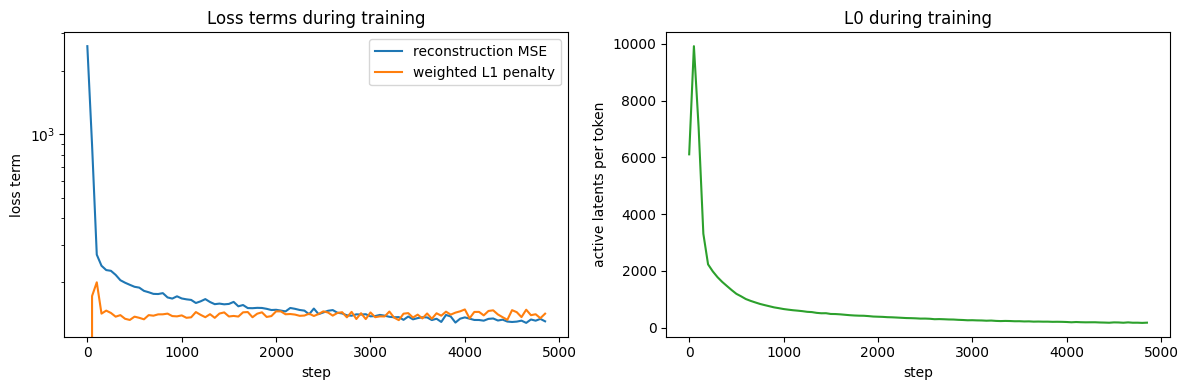

In [10]:
fig, (ax_mse, ax_l0) = plt.subplots(1, 2, figsize=(12, 4))
ax_mse.plot(history["step"], history["mse"], label="reconstruction MSE")
ax_mse.plot(history["step"], history["l1"], label="weighted L1 penalty")
ax_mse.set(xlabel="step", ylabel="loss term", title="Loss terms during training", yscale="log")
ax_mse.legend()
ax_l0.plot(history["step"], history["l0"], color="tab:green")
ax_l0.set(xlabel="step", ylabel="active latents per token", title="L0 during training")
plt.tight_layout()
plt.show()

### Evaluating the SAE

Four numbers describe an SAE on held-out text. **L0** is the mean number of nonzero latents per token. **Variance explained** is one minus the reconstruction error divided by the error of predicting the mean activation. **Loss recovered** splices the reconstruction into the forward pass and asks how much of the gap between the zeroed layer and the intact model the SAE closes. **Dead latents** never fire on the evaluation tokens (the published practice counts over 10 million tokens, so our small sample overestimates this one). Position 0 is skipped everywhere: the BOS activation is a huge outlier that the training data did not contain, so the splice keeps the original activation there.

In [11]:
@torch.no_grad()
def evaluate_sae(sae, tokens):
    """L0, variance explained, dead-latent fraction and loss recovered of `sae` on (N, T) tokens, skipping position 0."""
    l0_sum, n_tok, sq_err, sq_tot = 0.0, 0, 0.0, 0.0
    fired = torch.zeros(sae.cfg.d_sae, dtype=torch.bool, device=DEVICE)
    for i in range(0, len(tokens), EVAL_BATCH):
        acts = collect_acts(tokens[i:i + EVAL_BATCH])[:, 1:]            # (B, T-1, D_IN), BOS dropped
        feats = sae.encode(acts)                                       # (B, T-1, d_sae)
        recon = sae.decode(feats)                                      # (B, T-1, D_IN)
        l0_sum += (feats > 0).float().sum(-1).sum().item()
        n_tok += feats.shape[0] * feats.shape[1]
        sq_err += ((acts - recon) ** 2).sum().item()
        sq_tot += ((acts - acts.mean(dim=(0, 1), keepdim=True)) ** 2).sum().item()
        fired |= (feats > 0).flatten(0, 1).any(0)

    def splice_hook(acts, hook):
        recon = sae.decode(sae.encode(acts))
        recon[:, 0] = acts[:, 0]                                       # keep the BOS position untouched
        return recon

    loss_sae = mean_loss([(HOOK, splice_hook)])
    return {"L0": l0_sum / n_tok,
            "variance explained": 1 - sq_err / sq_tot,
            "loss recovered": 1 - (loss_sae - loss_clean) / (loss_zero - loss_clean),
            "spliced loss": loss_sae,
            "dead latents": 1 - fired.float().mean().item()}


own_metrics = evaluate_sae(sae, eval_tokens)
for name, value in own_metrics.items():
    print(f"{name:<20} {value:.3f}")

L0                   167.473
variance explained   0.582
loss recovered       0.890
spliced loss         4.601
dead latents         0.330


### Reading features from their top-activating tokens

A feature is understood from the tokens it fires on. We compute every latent's activation on the evaluation tokens, keep the features that fire on between 0.1% and 2% of tokens (dense features are rarely specific, very rare ones have too few examples here), and print the top-activating tokens of the strongest ones with context on each side, the layout of a Neuronpedia dashboard.

In [12]:
@torch.no_grad()
def feature_activations(sae, tokens):
    """Latent activations on all evaluation tokens, (N, T, d_sae), computed in batches."""
    return torch.cat([sae.encode(collect_acts(tokens[i:i + EVAL_BATCH])) for i in range(0, len(tokens), EVAL_BATCH)])


own_feats = feature_activations(sae, eval_tokens)
own_feats[:, 0] = 0                                                  # ignore the BOS position
density = (own_feats > 0).float().mean(dim=(0, 1))                   # (d_sae,): fraction of tokens each feature fires on
max_act = own_feats.amax(dim=(0, 1))                                 # (d_sae,)
candidates = torch.nonzero((density > 0.001) & (density < 0.02)).squeeze(1)
inspect = candidates[max_act[candidates].topk(N_INSPECT).indices].tolist()
print(f"{len(candidates):,} features in the density band, inspecting {inspect}")


def show_top_tokens(feats, tokens, feature, label):
    """Print the TOP_TOKENS highest activations of one feature with WINDOW tokens of context on each side."""
    flat = feats[:, :, feature].flatten()
    values, idx = flat.topk(TOP_TOKENS)
    print(f"\n{label} feature {feature}: max {flat.max():.1f}, fires on {(flat > 0).float().mean():.2%} of tokens")
    for v, i in zip(values.tolist(), idx.tolist()):
        seq, pos = divmod(i, tokens.shape[1])
        left = model.to_string(tokens[seq, max(1, pos - WINDOW):pos])
        token = model.to_string(tokens[seq, pos:pos + 1])
        right = model.to_string(tokens[seq, pos + 1:pos + 1 + WINDOW])
        print(f"  {v:6.1f}  {left!r} [[{token}]] {right!r}")


for f in inspect:
    show_top_tokens(own_feats, eval_tokens, f, "own")

4,480 features in the density band, inspecting [4384, 819, 10886, 11190]

own feature 4384: max 19.6, fires on 0.27% of tokens
    19.6  ' structure is a further challenge, since it requires not' [[ only]] ' theability to sense the magnetic field of an isolated'
    17.5  ' on the "target" state..\n\nnot' [[ only]] ' is the above imaging done to obtain a correlation to'
    17.2  " Claim table.\n\nWhat's needed is not" [[ just]] ' yet another O/RM tool (which are t'
    17.0  "ord Heath:\n\nWhat's needed is not" [[ just]] ' yet another O/RM tool (which are t'
    16.9  ' ideas delivered slickly through clever propaganda disseminated not' [[ just]] ' by fanatical Hindutva outfits but also a'
    12.8  ' itself, as if the detector is not' [[ just]] ' making the measurement but also affecting the measured or observed'
    11.8  ' the prime minister, although MPs in general, not' [[ just]] ' of the ruling party, do not like their term'
     8.4  ' dillema when deciding what to create was n

### Steering by clamping a feature

The hook encodes the residual stream with our SAE, reads the chosen latent, and moves the activation along that feature's decoder direction by exactly the amount that sets the latent to the clamp value. Clamping to zero removes the feature, clamping to several times its maximum forces it on: Templeton et al. clamped the Golden Gate Bridge feature to ten times its maximum and the model brought the bridge into every answer. Pick `STEER_FEATURE` from the inspected features after reading their tokens.

In [13]:
steer_feature = inspect[0] if STEER_FEATURE is None else STEER_FEATURE


def clamp_hook(acts, hook, sae, feature, value):
    """Set latent `feature` to `value` at every position by moving the residual stream along its decoder direction."""
    current = sae.encode(acts)[..., feature]                             # (B, T)
    return acts + (value - current).unsqueeze(-1) * sae.W_dec[feature]   # W_dec[feature]: (D_IN,)


@torch.no_grad()
def generate_text(fwd_hooks):
    torch.manual_seed(SEED)
    with model.hooks(fwd_hooks=fwd_hooks):
        return model.generate(GEN_PROMPT, max_new_tokens=MAX_NEW_TOKENS, temperature=0.7, top_p=0.9,
                              prepend_bos=True, verbose=False)


print(f"--- no steering\n{generate_text([])[len(GEN_PROMPT):].strip()}\n")
for m in CLAMP_MULTIPLES:
    value = m * max_act[steer_feature].item()
    hook = partial(clamp_hook, sae=sae, feature=steer_feature, value=value)
    print(f"--- feature {steer_feature} clamped to {m:g} x its max ({value:.0f})\n{generate_text([(HOOK, hook)])[len(GEN_PROMPT):].strip()}\n")

--- no steering
What you did that day was incredibly surreal. What you did that day was so hard that you couldn't even explain it to your family. It's one of those moments when you're not sure what to say. I want to tell you a story

--- feature 4384 clamped to 0 x its max (0)
What you did that day was incredibly surreal. What you did that day was so hard that you couldn't even explain it to your family. It's one of those moments when you're not sure what to say. I want to tell you a story

--- feature 4384 clamped to 5 x its max (98)
for the the that the the the the the a the the some individuals the the the the the the those the the a the be the the the physically physically the what is a some a isolated the the the the the a the the the the a the

--- feature 4384 clamped to 10 x its max (196)
physically the the that the physically the physically physically a the the some individuals the the the the physically physically those the physically physically the physically the physically 

### Comparison with a published SAE

Joseph Bloom's `gpt2-small-res-jb` SAEs cover every residual-stream layer of GPT-2 small with 24,576 latents each, trained on 300 million OpenWebText tokens. We load the one at our hook, run the same evaluation, and ask how many of our feature directions already exist in the larger dictionary: for every live feature of ours, the best cosine similarity with any of its decoder directions. Each inspected feature is paired with its closest published feature and that feature's Neuronpedia dashboard.

cfg.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

blocks.7.hook_resid_pre/sae_weights.safe(…): reconstructing file:   0%|          |  0.00B /  151MB            

blocks.7.hook_resid_pre/sae_weights.safe(…): downloading bytes:           |  0.00B            

blocks.7.hook_resid_pre/sparsity.safeten(…): reconstructing file:   0%|          |  0.00B / 98.4kB            

blocks.7.hook_resid_pre/sparsity.safeten(…): downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/sae_lens/saes/sae.py:256: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


metric                   ours  pretrained
L0                    167.473      68.602
variance explained      0.582       0.771
loss recovered          0.890       0.958
spliced loss            4.601       3.935
dead latents            0.330       0.006
d_sae                  12,288      24,576


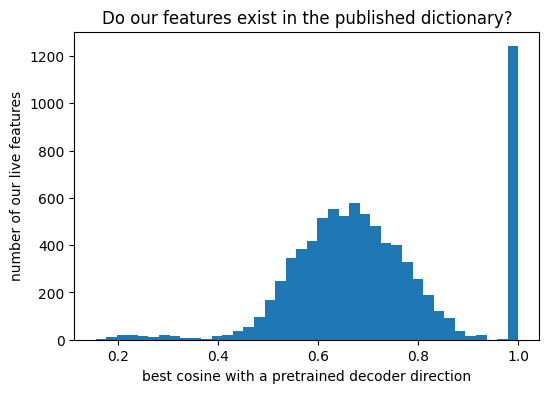

live features with a match above 0.9: 15%
own feature 4384 -> pretrained feature 378 (cos 0.84)  https://www.neuronpedia.org/gpt2-small/7-res-jb/378
own feature 819 -> pretrained feature 10030 (cos 0.83)  https://www.neuronpedia.org/gpt2-small/7-res-jb/10030
own feature 10886 -> pretrained feature 20514 (cos 0.77)  https://www.neuronpedia.org/gpt2-small/7-res-jb/20514
own feature 11190 -> pretrained feature 15808 (cos 0.78)  https://www.neuronpedia.org/gpt2-small/7-res-jb/15808


In [14]:
pretrained = SAE.from_pretrained(release=PRETRAINED_RELEASE, sae_id=HOOK, device=DEVICE)
pretrained.eval()
pre_metrics = evaluate_sae(pretrained, eval_tokens)

print(f"{'metric':<20} {'ours':>8} {'pretrained':>11}")
for name in own_metrics:
    print(f"{name:<20} {own_metrics[name]:>8.3f} {pre_metrics[name]:>11.3f}")
print(f"{'d_sae':<20} {sae.cfg.d_sae:>8,} {pretrained.cfg.d_sae:>11,}")

own_dirs = F.normalize(sae.W_dec.detach(), dim=-1)                     # (d_sae, D_IN)
pre_dirs = F.normalize(pretrained.W_dec.detach(), dim=-1)              # (d_sae_pre, D_IN)
best_cos, best_idx = [], []
for i in range(0, own_dirs.shape[0], 1024):                            # chunked: the full similarity matrix is 12k x 25k
    sims = own_dirs[i:i + 1024] @ pre_dirs.T
    values, idx = sims.max(dim=1)
    best_cos.append(values)
    best_idx.append(idx)
best_cos, best_idx = torch.cat(best_cos), torch.cat(best_idx)
alive = density > 0

plt.figure(figsize=(6, 4))
plt.hist(best_cos[alive].cpu().numpy(), bins=40)
plt.xlabel("best cosine with a pretrained decoder direction")
plt.ylabel("number of our live features")
plt.title("Do our features exist in the published dictionary?")
plt.show()
print(f"live features with a match above 0.9: {(best_cos[alive] > 0.9).float().mean():.0%}")
for f in inspect:
    print(f"own feature {f} -> pretrained feature {best_idx[f].item()} (cos {best_cos[f]:.2f})  "
          f"https://www.neuronpedia.org/{NEURONPEDIA}/{best_idx[f].item()}")

### A mean-difference steering vector for a known concept

When the concept is known in advance, no dictionary is needed: the difference between the mean activations of two groups of inputs is a direction that separates them (Turner et al., 2023, Arditi et al., 2024). We take positive and negative SST-2 sentences at the same hook, check how well the direction classifies held-out sentences, steer with it in both directions, and ask which of our SAE features it is made of.

In [15]:
sst2 = load_dataset("stanfordnlp/sst2")


def sentences(split, label, n):
    return [r["sentence"] for r in split.filter(lambda r: r["label"] == label).select(range(n))]


@torch.no_grad()
def mean_activation(texts):
    """Per-sentence mean residual-stream activation at HOOK, excluding BOS: (n, D_IN)."""
    return torch.stack([collect_acts(model.to_tokens(s))[0, 1:].mean(0) for s in texts])


pos = mean_activation(sentences(sst2["train"], 1, N_PER_CLASS))
neg = mean_activation(sentences(sst2["train"], 0, N_PER_CLASS))
direction = pos.mean(0) - neg.mean(0)                                  # (D_IN,)
unit = direction / direction.norm()
threshold = ((pos.mean(0) + neg.mean(0)) / 2) @ unit

val = sst2["validation"].select(range(N_VAL_SENTENCES))
projections = mean_activation(val["sentence"]) @ unit
accuracy = ((projections > threshold).long() == torch.tensor(val["label"], device=DEVICE)).float().mean()
print(f"held-out accuracy of the mean-difference direction: {accuracy:.1%} (|direction| = {direction.norm():.1f})")

for c in STEER_COEFFS:
    print(f"\n--- add {c:+g} x mean difference\n{generate_text([(HOOK, lambda acts, hook: acts + c * direction)])[len(GEN_PROMPT):].strip()}")

cos = F.cosine_similarity(sae.W_dec.detach(), unit.unsqueeze(0), dim=-1)   # (d_sae,)
print("\nown SAE features most aligned with the sentiment direction:")
for v, f in zip(*[t.tolist() for t in cos.topk(5)]):
    print(f"  cos {v:.2f}  feature {f}  fires on {density[f]:.2%} of tokens")

README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Filter:   0%|          | 0/67349 [00:00<?, ? examples/s]

Filter:   0%|          | 0/67349 [00:00<?, ? examples/s]

held-out accuracy of the mean-difference direction: 70.0% (|direction| = 6.3)

--- add -8 x mean difference
It was supposed to be about the same as I have been doing for two days.

I am going to make it be funny, because I am going to be able to even talk to my phone. I'm going to call my daughter.

--- add +8 x mean difference
I am a professional, and I have been able to achieve the quest of being able to combine the attitude and the lifestyle to the level of the professional and the work of creating the profession.

I have been involved in the upbringing and

own SAE features most aligned with the sentiment direction:
  cos 0.43  feature 4670  fires on 0.79% of tokens
  cos 0.41  feature 4400  fires on 3.47% of tokens
  cos 0.39  feature 314  fires on 1.40% of tokens
  cos 0.38  feature 1253  fires on 2.26% of tokens
  cos 0.35  feature 1728  fires on 0.92% of tokens


**What to notice**

L0 and variance explained pull against each other, and our SAE, trained on a few tens of millions of tokens, explains less variance and recovers less loss than the published one trained on 300 million. The gap in loss recovered is larger than the gap in variance explained: the error an SAE leaves is not random noise but the part of the computation it failed to capture. Even a short run finds features that read cleanly from their top tokens, and many of our live decoder directions have a near-duplicate in the larger dictionary, so the two dictionaries agree on the common features. Clamping a feature changes what the model writes about, and a large clamp costs fluency. The mean-difference direction classifies sentiment well with no dictionary at all, and the SAE features aligned with it show which learned features a known concept is made of.

We save the SAE in SAELens's inference format (a `cfg.json` and a `safetensors` file), reload it as a plain `SAE` and check that it reconstructs identically.

In [16]:
SAVE_DIR = "gpt2_small_resid7_sae"
sae.save_inference_model(SAVE_DIR)

reloaded = SAE.load_from_disk(SAVE_DIR, device=DEVICE)
acts = collect_acts(eval_tokens[:4])
same = torch.allclose(reloaded.decode(reloaded.encode(acts)), sae.decode(sae.encode(acts)), atol=1e-4)
print(f"reloaded as {type(reloaded).__name__} with {reloaded.cfg.d_sae:,} latents | identical reconstruction: {same}")

reloaded as StandardSAE with 12,288 latents | identical reconstruction: True


## Summary

- A sparse autoencoder rewrites a layer's activations as a sparse sum of learned directions, trained with a reconstruction loss and an $L_1$ penalty whose coefficient sets the trade-off between sparsity and faithfulness.
- The right scorecard combines L0 with variance explained, loss recovered and dead latents: reconstruction alone hides how much of the model's computation the dictionary misses.
- Features are read from their top-activating tokens, and writing to one, by clamping its latent along the decoder direction, steers generation at the cost of fluency when pushed far.
- For a concept you can name, a mean-difference vector is a strong probe and steering direction without any dictionary, and its alignment with SAE features shows what it is made of.

## Exercises

1. **Sparsity coefficient.** Set `L1_COEFFICIENT` to 2 and to 10 and retrain. Compare L0, variance explained, loss recovered and the dead-latent fraction, and place the three runs on an L0 against loss-recovered plot.
2. **Dictionary width.** Set `EXPANSION = 32` to match the published SAE. Compare the metrics and the share of features with a match above 0.9.
3. **More tokens.** Double `TRAINING_TOKENS` and compare the curves and the final metrics with this run. Estimate from the two points how many tokens the published SAE's numbers would need.
4. **Another layer.** Set `LAYER = 3` (the hook follows) and retrain. Compare L0 and the kind of features that appear in the top-token windows with those of layer 7.
5. **Steering strength.** Set `CLAMP_MULTIPLES = [2.0, 20.0, 50.0]` and `STEER_COEFFS = [-20.0, 20.0]`. Describe where the text first changes topic and where it stops being fluent.

## Further Reading

- [Bricken et al., 2023. Towards Monosemanticity: Decomposing Language Models With Dictionary Learning](https://transformer-circuits.pub/2023/monosemantic-features/index.html)
- [Templeton et al., 2024. Scaling Monosemanticity: Extracting Interpretable Features from Claude 3 Sonnet](https://transformer-circuits.pub/2024/scaling-monosemanticity/index.html)
- [Gao et al., 2024. Scaling and Evaluating Sparse Autoencoders](https://arxiv.org/abs/2406.04093)
- [Rajamanoharan et al., 2024. Jumping Ahead: Improving Reconstruction Fidelity with JumpReLU Sparse Autoencoders](https://arxiv.org/abs/2407.14435)
- [Lieberum et al., 2024. Gemma Scope: Open Sparse Autoencoders Everywhere All At Once on Gemma 2](https://arxiv.org/abs/2408.05147)
- [Turner et al., 2023. Steering Language Models With Activation Engineering](https://arxiv.org/abs/2308.10248)
- [Arditi et al., 2024. Refusal in Language Models Is Mediated by a Single Direction](https://arxiv.org/abs/2406.11717)
- [Bloom, 2024. Open Source Sparse Autoencoders for all Residual Stream Layers of GPT2-Small](https://www.lesswrong.com/posts/f9EgfLSurAiqRJySD/open-source-sparse-autoencoders-for-all-residual-stream)

### Contributed by: Mohamed Eltayeb